In [1]:
import pandas as pd

chicks = pd.read_csv("chickwts.csv")

chicks.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

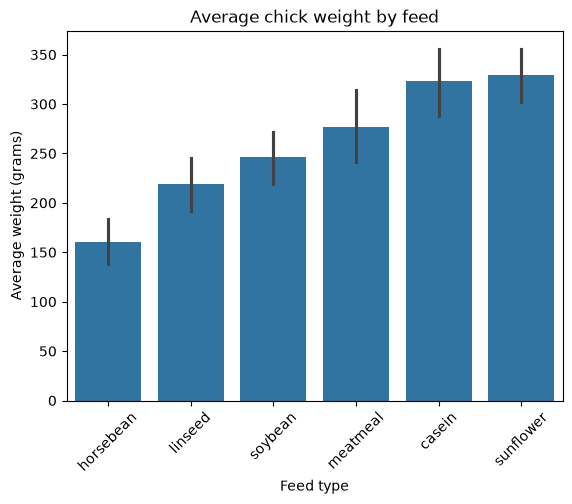

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=chicks,
    x="feed",
    y="weight",
    order=chicks.groupby("feed")["weight"].mean().sort_values().index
)

plt.title("Average chick weight by feed")
plt.xlabel("Feed type")
plt.ylabel("Average weight (grams)")
plt.xticks(rotation=45)

plt.show()

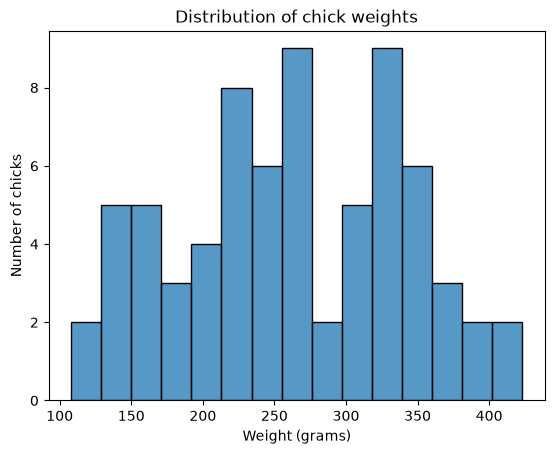

In [3]:
sns.histplot(data=chicks, x="weight", bins=15)

plt.title("Distribution of chick weights")
plt.xlabel("Weight (grams)")
plt.ylabel("Number of chicks")

plt.show()

In [4]:
museum = pd.read_csv("museum_visitors.csv")

museum.head()

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694


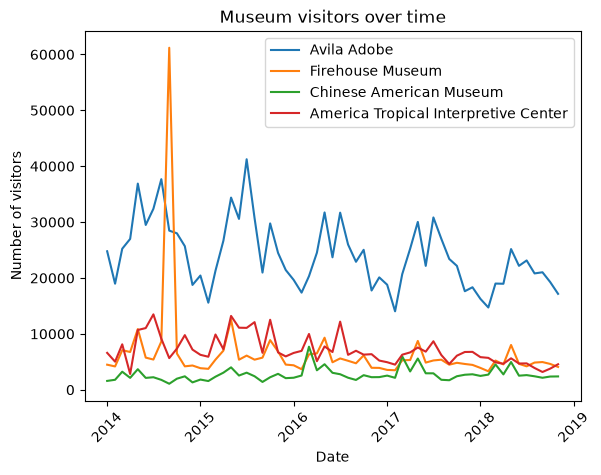

In [5]:
museum["Date"] = pd.to_datetime(museum["Date"])

sns.lineplot(data=museum, x="Date", y="Avila Adobe", label="Avila Adobe")
sns.lineplot(data=museum, x="Date", y="Firehouse Museum", label="Firehouse Museum")
sns.lineplot(data=museum, x="Date", y="Chinese American Museum", label="Chinese American Museum")
sns.lineplot(data=museum, x="Date", y="America Tropical Interpretive Center",
             label="America Tropical Interpretive Center")

plt.title("Museum visitors over time")
plt.xlabel("Date")
plt.ylabel("Number of visitors")
plt.legend()
plt.xticks(rotation=45)

plt.show()

Avila adobe museum has a sitable visitors generally has the higher visitors over time .except the perioed 2014and 2015 the firehouse museum has the higest visitors.

In [6]:
sales = pd.read_csv("sales_clean.csv")

sales.head()

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405


In [7]:
sales.columns

Index(['order_id', 'date', 'product', 'price', 'qty', 'zip'], dtype='str')

In [8]:
sales["revenue"] = sales["price"] * sales["qty"]

sales.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


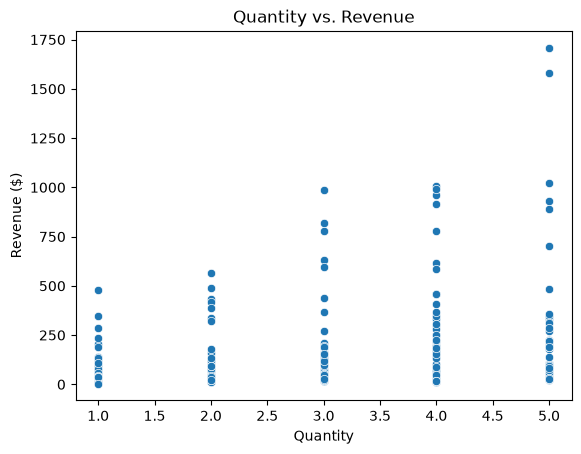

In [9]:
sns.scatterplot(data=sales, x="qty", y="revenue")

plt.title("Quantity vs. Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue ($)")

plt.show()

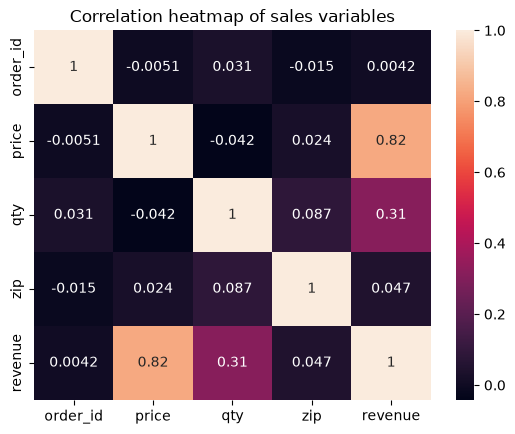

In [10]:
sns.heatmap(sales.corr(numeric_only=True), annot=True)

plt.title("Correlation heatmap of sales variables")

plt.show()

the null hypothesis roughly all the chiken between 250 to 260 gram.

In [11]:
from scipy.stats import ttest_ind

casein = chicks[chicks["feed"] == "casein"]["weight"]
horsebean = chicks[chicks["feed"] == "horsebean"]["weight"]

ttest_ind(casein, horsebean)

TtestResult(statistic=np.float64(7.019741040397541), pvalue=np.float64(8.254541016953185e-07), df=np.float64(20.0))

The conclusion Casein-fed chicks were on average 163.38 grams heavier than horsebean-fed chicks (p < 0.001), so we reject the null hypothesis. However, this result shouldn't be accurate because it is short list of data

Honest-chart audit I used clear labels for the dates and museum names so it is easy to see which line belongs to each museum. I also labeled the y-axis as “Number of visitors” so the measurement is clear.